In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 

# set cosmology (for mdpl2)
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h

import halotools.sim_manager as sim_manager
import halotools.mock_observables as mock_observables

from compact.velocities.pw_moments import *
from compact.velocities.moments import *
from compact.catalog.accumulate import *
from compact.catalog.bin import *
from compact.streaming import *
from compact.tpcf import *
from compact.plot import *
from compact.model import *

from scipy.interpolate import UnivariateSpline

# reload project when changes are made
%load_ext autoreload
%autoreload 2

# plotting config
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})
plt.rcParams['axes.labelsize'] = 20

import os
import warnings
warnings.filterwarnings('ignore')

import psutil
psutil.Process().nice(10)

from pairhist import *

from scipy.optimize import curve_fit

In [2]:
# define grids

r_perp = np.linspace(5, 140, 135+1)
r_los = np.linspace(5, 140, 135+1)

r_p = 0.5*(r_perp[1:]+r_perp[:-1])
r_l = 0.5*(r_los[1:]+r_los[:-1])


r_p_2d, r_l_2d = np.meshgrid(r_p, r_l, indexing='ij')
r = np.sqrt(r_p_2d**2 + r_l_2d**2)

mu = r_p_2d/r 

x = r * ( 1 - mu ) 
x2 = r - r_p

In [3]:
# Only this subset of the 2000 latin hypercube sims is on spiffball.
SIMS = [
    1402, 1655, 1740, 1791, 1807, 1820, 1839, 1861, 1889, 1902, 1911, 1915, 1923,
    1930, 1936, 1945, 1952, 1962, 1966, 1974, 1979, 1984, 1988, 1992, 1996,
    1625, 1656, 1757, 1793, 1810, 1824, 1852, 1871, 1894, 1906, 1912, 1916, 1927,
    1933, 1937, 1948, 1955, 1963, 1967, 1975, 1980, 1985, 1989, 1993, 1997,
    1630, 1659, 1764, 1795, 1818, 1826, 1857, 1877, 1897, 1907, 1913, 1919, 1928,
    1934, 1943, 1949, 1956, 1964, 1970, 1976, 1982, 1986, 1990, 1994, 1998,
    1640, 1704, 1769, 1797, 1819, 1835, 1859, 1887, 1898, 1909, 1914, 1921, 1929,
    1935, 1944, 1950, 1960, 1965, 1972, 1977, 1983, 1987, 1991, 1995, 590,
]

sim = SIMS[0] #check


HALO_TMPL = ('/spiffball/edgarmsc/simulations/Quijote/Halos/Rockstar/'
             f'latin_hypercube_HR/{sim}/hlist_4.hdf5')
COSMO_TMPL = ('/spiffball/edgarmsc/simulations/Quijote/Snapshots/'
              f'latin_hypercube_HR_cosmo/Cosmo_params_{sim}.dat')
OUT_DIR = ('/spiffball/cosweeney/simulations/Quijote/halos/'
           f'latin_hypercube_HR/{sim}/data/')
SB_TMPL = ('/spiffball/cosweeney/simulations/Quijote/halos/'
           f'latin_hypercube_HR/{sim}/SBp/')
LOG_TMPL = '/spiffball/cosweeney/simulations/Quijote/logs/pairhist_{sim}.log'
OUT_NAME = 'pairhist_massbin.h5'


COSMO_COLS = ['Om', 'Ob', 'h', 'ns', 's8']


def read_cosmology(sim):
    """Read one sim's cosmology from its Cosmo_params_<sim>.dat file."""
    df = pd.read_csv(COSMO_TMPL.format(sim=sim), sep=r'\s+', header=None,
                     names=COSMO_COLS)
    return dict(zip(COSMO_COLS, df.values[0]))


box_length = 1000 #Mpc/h, quijote box side length

In [4]:
cosmos = []
cosmo_arr = np.zeros((len(SIMS), 5))

PARAM_NAMES = ['Om', 'Ob', 'h', 'ns', 's8']  

for si, sim in enumerate(SIMS):

    COSMO_TMPL = ('/spiffball/edgarmsc/simulations/Quijote/Snapshots/'
                f'latin_hypercube_HR_cosmo/Cosmo_params_{sim}.dat')

    sim_cosmo = read_cosmology(sim)

    params = {'flat': True, 'H0': 100 * sim_cosmo['h'], 'Om0': sim_cosmo['Om'], 'Ob0': sim_cosmo['Ob'], 'sigma8': sim_cosmo['s8'], 'ns': sim_cosmo['ns']}

    cosmo = cosmology.setCosmology('myCosmo', params)

    cosmos.append(cosmo)

    cosmo_arr[si] = [sim_cosmo[k] for k in PARAM_NAMES]


In [ ]:
ST_pars = np.full((len(cosmos), len(r_p), len(r_l), 3), np.nan) 
ST_errs = np.full(ST_pars.shape, np.nan) 
meas_sigv = np.full((len(cosmos), len(r_p), len(r_l)), np.nan)

nus   = 6
REBIN = 5        # 20 km/s fine bins -> 100 km/s, matching your linspace(...,51)
N_MIN = 500      # replaces the isnan(hist) guard

for si, sim in tqdm(enumerate(SIMS)):

    OUT_DIR = ('/spiffball/cosweeney/simulations/Quijote/halos/'
            f'latin_hypercube_HR/{sim}/data/')
    OUT_NAME = 'pairhist_massbin.h5'
    
    h = PairHist.load(OUT_DIR+OUT_NAME)
    assert len(r_p) == h.n_R and len(r_l) == h.n_l

    cent_fine = h.v_centers                          # km/s, conv applied at accumulation
    dv        = (cent_fine[1] - cent_fine[0]) * REBIN
    cent      = cent_fine.reshape(-1, REBIN).mean(axis=1)

    for j in range(len(r_p)):
        for i in range(len(r_l)):
            n = h.n[0, j, i]
            if n < N_MIN:
                continue


            r_3d  = np.sqrt(r_p[j]**2 + r_l[i]**2)
            theta = np.arctan2(r_l[i], r_p[j])
            sin   = np.sin(theta)

            #peak = interps[k](r_3d) * sin #mean_vr_interp(r_3d)

            mu    = h.sum_v[0, j, i] / n
            width = np.sqrt(max(h.sum_v2[0, j, i] / n - mu**2, 0.0))

            counts   = h.counts[0, j, i].reshape(-1, REBIN).sum(axis=1)
            sel      = np.abs(cent - mu) <= 2500
            c_w, x_w = counts[sel], cent[sel]
            if c_w.sum() == 0:
                continue

            hist = c_w / (c_w.sum() * dv)            # matches density=True over the window

            try:
                p, c = curve_fit(lambda x, xi, omega, alpha: skewed_t_pdf(x, xi=xi, omega=omega, alpha=alpha, nu=nus),
                                x_w, hist, p0=[mu, width, -0.1], method='lm', maxfev=5_000)
            except RuntimeError:
                continue
            ST_pars[si, j, i] = p
            ST_errs[si, j, i] = np.sqrt(np.diag(c))
            meas_sigv[si, j, i] = width 

1it [03:51, 231.65s/it]


KeyboardInterrupt: 

In [37]:
from concurrent.futures import ProcessPoolExecutor

nus   = 6
REBIN = 5
N_MIN = 100 #500, adjust if hists too noisy. 


def fit_sim(sim):
    OUT_DIR = ('/spiffball/cosweeney/simulations/Quijote/halos/'
               f'latin_hypercube_HR/{sim}/data/')
    h = PairHist.load(OUT_DIR + 'pairhist_massbin.h5')
    assert len(r_p) == h.n_R and len(r_l) == h.n_l

    pars = np.full((len(r_p), len(r_l), 3), np.nan)
    errs = np.full(pars.shape, np.nan)
    sigv = np.full((len(r_p), len(r_l)), np.nan)

    cent_fine = h.v_centers
    dv        = (cent_fine[1] - cent_fine[0]) * REBIN
    cent      = cent_fine.reshape(-1, REBIN).mean(axis=1)

    for j in range(len(r_p)):
        for i in range(len(r_l)):
            n = h.n[0, j, i]
            if n < N_MIN:
                continue

            mu    = h.sum_v[0, j, i] / n
            width = np.sqrt(max(h.sum_v2[0, j, i] / n - mu**2, 0.0))

            counts   = h.counts[0, j, i].reshape(-1, REBIN).sum(axis=1)
            sel      = np.abs(cent - mu) <= 2500
            c_w, x_w = counts[sel], cent[sel]
            if c_w.sum() == 0:
                continue

            hist = c_w / (c_w.sum() * dv)

            try:
                p, c = curve_fit(lambda x, xi, omega, alpha: skewed_t_pdf(x, xi=xi, omega=omega, alpha=alpha, nu=nus),
                                 x_w, hist, p0=[mu, width, -0.1], method='lm', maxfev=5_000)
            except RuntimeError:
                continue
            pars[j, i] = p
            errs[j, i] = np.sqrt(np.diag(c))
            sigv[j, i] = width

    return pars, errs, sigv


ST_pars   = np.full((len(cosmos), len(r_p), len(r_l), 3), np.nan)
ST_errs   = np.full(ST_pars.shape, np.nan)
meas_sigv = np.full((len(cosmos), len(r_p), len(r_l)), np.nan)

with ProcessPoolExecutor(max_workers=84) as ex:
    for si, (p, e, s) in enumerate(tqdm(ex.map(fit_sim, SIMS), total=len(SIMS))):
        ST_pars[si], ST_errs[si], meas_sigv[si] = p, e, s

100%|██████████| 100/100 [07:12<00:00,  4.32s/it] 


In [35]:
import numpy as np, traceback
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

# 0=ok 1=low_n 2=empty_window 3=runtime_error 4=other_exception
def diagnose_sim(sim):
    OUT_DIR = ('/spiffball/cosweeney/simulations/Quijote/halos/'
               f'latin_hypercube_HR/{sim}/data/')
    code = np.zeros((len(r_p), len(r_l)), dtype=np.int8)
    ncell = np.full((len(r_p), len(r_l)), -1.0)

    try:
        h = PairHist.load(OUT_DIR + 'pairhist_massbin.h5')
    except Exception as exc:
        return sim, code, ncell, f'LOAD FAILED: {type(exc).__name__}: {exc}', []
    if not (len(r_p) == h.n_R and len(r_l) == h.n_l):
        return sim, code, ncell, f'SHAPE MISMATCH: {h.n_R}x{h.n_l}', []

    cent_fine = h.v_centers
    dv        = (cent_fine[1] - cent_fine[0]) * REBIN
    cent      = cent_fine.reshape(-1, REBIN).mean(axis=1)
    exc_log   = []

    for j in range(len(r_p)):
        for i in range(len(r_l)):
            n = h.n[0, j, i]
            ncell[j, i] = n
            if n < N_MIN:
                code[j, i] = 1
                continue

            mu     = h.sum_v[0, j, i] / n
            width  = np.sqrt(max(h.sum_v2[0, j, i] / n - mu**2, 0.0))
            counts = h.counts[0, j, i].reshape(-1, REBIN).sum(axis=1)
            sel    = np.abs(cent - mu) <= 2500
            c_w, x_w = counts[sel], cent[sel]
            if c_w.sum() == 0:
                code[j, i] = 2
                continue

            hist = c_w / (c_w.sum() * dv)
            try:
                curve_fit(lambda x, xi, omega, alpha: skewed_t_pdf(x, xi=xi, omega=omega, alpha=alpha, nu=nus),
                          x_w, hist, p0=[mu, width, -0.1], method='lm', maxfev=5_000)
            except RuntimeError:
                code[j, i] = 3
            except Exception as exc:
                code[j, i] = 4
                if len(exc_log) < 5:
                    exc_log.append((j, i, n, mu, width, f'{type(exc).__name__}: {exc}'))

    return sim, code, ncell, 'ok', exc_log


codes  = np.zeros((len(SIMS), len(r_p), len(r_l)), dtype=np.int8)
ncells = np.zeros((len(SIMS), len(r_p), len(r_l)))
status = {}

with ProcessPoolExecutor(max_workers=32) as ex:
    for si, (sim, c, nc, st, log) in enumerate(tqdm(ex.map(diagnose_sim, SIMS), total=len(SIMS))):
        codes[si], ncells[si], status[sim] = c, nc, st
        for entry in log:
            print(sim, entry)

100%|██████████| 100/100 [08:06<00:00,  4.86s/it] 


0/100 sims failed outright
            ok:   1306537 (71.69%)
         low_n:    515963 (28.31%)
  empty_window:         0 ( 0.00%)
 runtime_error:         0 ( 0.00%)
     other_exc:         0 ( 0.00%)
n in skipped cells — median 272, 90th pct 452
  N_MIN= 100 ->  3.60% of cells skipped
  N_MIN= 200 ->  9.53% of cells skipped
  N_MIN= 300 -> 15.97% of cells skipped
  N_MIN= 500 -> 28.31% of cells skipped
worst sims: [(np.int64(1897), 1.0), (np.int64(1740), 1.0), (np.int64(1877), 1.0), (np.int64(1915), 0.87), (np.int64(1992), 0.78), (np.int64(1982), 0.768), (np.int64(1963), 0.752), (np.int64(1966), 0.73), (np.int64(1949), 0.727), (np.int64(1927), 0.663)]
best  sims: [(np.int64(1936), 0.062), (np.int64(1967), 0.061), (np.int64(1935), 0.056), (np.int64(1975), 0.054), (np.int64(1986), 0.053)]


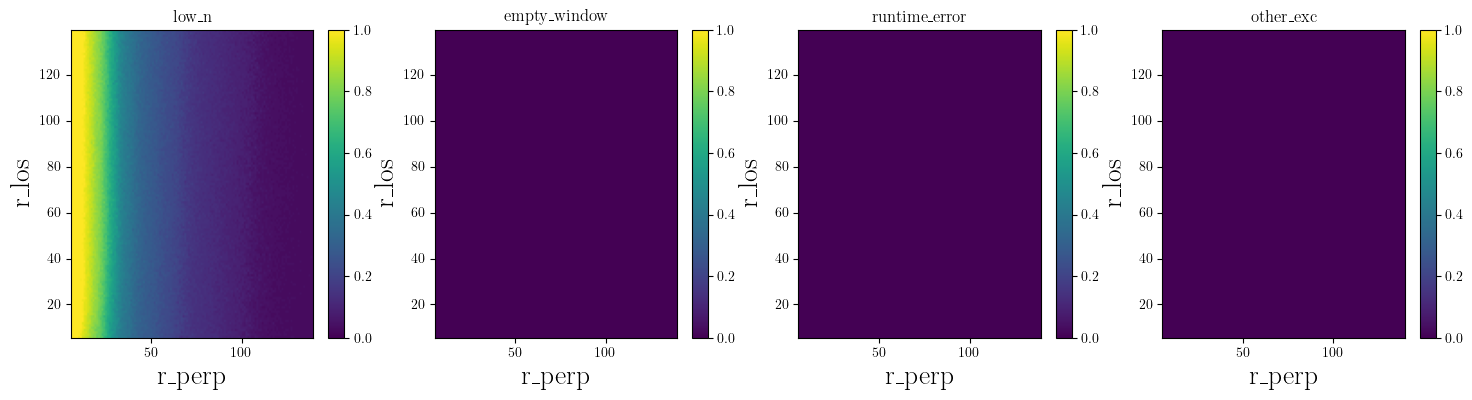

In [36]:
labels = ['ok', 'low_n', 'empty_window', 'runtime_error', 'other_exc']

# 1. whole-sim failures first — these masquerade as per-cell failures
bad = {s: v for s, v in status.items() if v != 'ok'}
print(f'{len(bad)}/{len(SIMS)} sims failed outright')
for s, v in list(bad.items())[:10]:
    print(' ', s, v)

# 2. global breakdown over the healthy sims
ok_mask = np.array([status[s] == 'ok' for s in SIMS])
tally = np.bincount(codes[ok_mask].ravel(), minlength=5)
for lab, cnt in zip(labels, tally):
    print(f'{lab:>14}: {cnt:>9} ({100*cnt/tally.sum():5.2f}%)')

# 3. is low_n the story? where does N_MIN cut?
low = ncells[ok_mask][codes[ok_mask] == 1]
if low.size:
    print('n in skipped cells — median %.0f, 90th pct %.0f' % (np.median(low), np.percentile(low, 90)))
    for thresh in (100, 200, 300, 500):
        print(f'  N_MIN={thresh:4d} -> {100*np.mean(ncells[ok_mask] < thresh):5.2f}% of cells skipped')

# 4. per-sim failure fraction — uniform, or concentrated in a few cosmologies?
frac = (codes[ok_mask] != 0).mean(axis=(1, 2))
order = np.argsort(frac)[::-1]
print('worst sims:', [(np.array(SIMS)[ok_mask][k], round(float(frac[k]), 3)) for k in order[:10]])
print('best  sims:', [(np.array(SIMS)[ok_mask][k], round(float(frac[k]), 3)) for k in order[-5:]])

# 5. where in the grid — expect an r_los / r_perp edge if it's occupancy
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, k in zip(axes, [1, 2, 3, 4]):
    im = ax.imshow((codes[ok_mask] == k).mean(axis=0).T, origin='lower', aspect='auto',
                   extent=[r_p[0], r_p[-1], r_l[0], r_l[-1]], vmin=0, vmax=1)
    ax.set(title=labels[k], xlabel='r_perp', ylabel='r_los')
    plt.colorbar(im, ax=ax)

In [12]:
# save pars

save_path = '/spiffball/cosweeney/simulations/Quijote/halos/latin_hypercube_HR/data/ST_pars_cosmo.h5'

with h5.File(save_path, 'w') as hdf:
    hdf.create_dataset('ST_pars', data=ST_pars)
    hdf.create_dataset('ST_errs', data=ST_errs)
    hdf.create_dataset('meas_sigv', data=meas_sigv)

In [12]:
# load pars 

save_path = '/spiffball/cosweeney/simulations/Quijote/halos/latin_hypercube_HR/data/ST_pars_cosmo.h5'

with h5.File(save_path, 'r') as hdf:
    ST_pars = hdf['ST_pars'][()]
    ST_errs = hdf['ST_errs'][()]
    meas_sigv = hdf['meas_sigv'][()]

In [6]:
# measure radial velocity profiles 

from scipy.interpolate import InterpolatedUnivariateSpline

def vr_profile(h, k, r_edges=None, r_max_trust=None):
    """Pair-weighted <v_r>(r) and sigma_vr(r) for mass bin k.

    Returns (r_eff, mean_vr, sigma_vr, n_pairs), all length len(r_edges)-1.
    r_eff is the pair-weighted mean radius in each bin, not the bin centre.
    Units follow the accumulator -- km/s if conv was applied at accumulation.
    """
    Rc = 0.5 * (h.R_edges[1:] + h.R_edges[:-1])
    lc = 0.5 * (h.rlos_edges[1:] + h.rlos_edges[:-1])
    r3 = np.sqrt(Rc[:, None]**2 + lc[None, :]**2).ravel()

    n = h.n[k].ravel().astype(float)
    s1 = h.sum_vr[k].ravel()
    s2 = h.sum_vr2[k].ravel()

    if r_edges is None:
        # default: 2 Mpc/h bins out to the largest radius with full angular
        # coverage (beyond R_edges[-1] only the cylinder corners contribute)
        top = r_max_trust if r_max_trust is not None else h.R_edges[-1]
        r_edges = np.arange(0.0, top + 2.0, 2.0)

    nb_bins = len(r_edges) - 1
    idx = np.searchsorted(r_edges, r3, side='right') - 1
    ok = (idx >= 0) & (idx < nb_bins) & (n > 0)

    def acc(w):
        return np.bincount(idx[ok], weights=w[ok], minlength=nb_bins)

    N = acc(n)
    r_eff = np.where(N > 0, acc(n * r3) / np.where(N > 0, N, 1), np.nan)
    mu = np.where(N > 0, acc(s1) / np.where(N > 0, N, 1), np.nan)
    m2 = np.where(N > 0, acc(s2) / np.where(N > 0, N, 1), np.nan)
    sd = np.sqrt(np.maximum(m2 - mu**2, 0.0))
    return r_eff, mu, sd, N.astype(np.int64)


def make_vr_interp(h, k, r_edges=None, r_max_trust=None, n_min=1000, ext=3):
    """Spline interpolator for <v_r>(r), analogous to mean_vr_r_interp.

    ext=3 clamps to the end values outside the fitted range rather than
    extrapolating or returning NaN -- your r_3d reaches ~198 Mpc/h at the grid
    corners, and a spline let loose out there will do something wild.
    """
    r, mu, _, N = vr_profile(h, k, r_edges, r_max_trust)
    good = np.isfinite(mu) & (N >= n_min)
    if good.sum() < 4:
        raise ValueError(f'mass bin {k}: only {good.sum()} usable radial bins')
    return InterpolatedUnivariateSpline(r[good], mu[good], k=3, ext=ext)

In [7]:
sim_interps = []
for sim in SIMS:
    OUT_DIR = ('/spiffball/cosweeney/simulations/Quijote/halos/'
        f'latin_hypercube_HR/{sim}/data/')
    
    h = PairHist.load(OUT_DIR+OUT_NAME)
    interp = make_vr_interp(h, 0) 

    sim_interps.append(interp)


In [8]:
# compute 1-D isotropic halo velocity dispersion for halos in sims. How different from one another, MDPL2?

# non-linear Pk instead 
import camb
from camb import model

sigmas = np.zeros(len(cosmos))

for si, sim in enumerate(SIMS):

    camb_params = [cosmos[si].H0, cosmos[si].Ombh2, cosmos[si].Omh2 - cosmos[si].Ombh2, cosmos[si].ns]

    def get_sigma0_nl(params, redshift, kmax=10.0, npoints=500):

        pars = camb.set_params(H0=params[0], ombh2=params[1], omch2=params[2], ns=params[3])
        pars.set_matter_power(redshifts=[redshift], kmax=10.0) 
        pars.NonLinear = model.NonLinear_both

        results = camb.get_results(pars)
        kh_nl, z_nl, pk_nl = results.get_matter_power_spectrum(
            minkh=1e-4, maxkh=5.0, npoints=500
        )
        pk_nl = pk_nl[0] 

        h = params[0] / 100.0

        Om0 = (params[1] + params[2]) / h**2
        Omz = Om0 * (1.0 + redshift)**3 / (params[0] / (100.0 * h))**2
        f = Omz**0.55 # growth rate

        a = 1/(1+redshift)
        conv = a * params[0] / h

        sigma0_nl_sq = (f * conv)**2 / (6 * np.pi**2) * simpson(pk_nl, kh_nl)
        sigma0_nl = np.sqrt(sigma0_nl_sq)

        return sigma0_nl

        
    sigma = get_sigma0_nl(camb_params, 0.0)
    #print(sigma)

    sigmas[si] = sigma


(-500.0, 450.0)

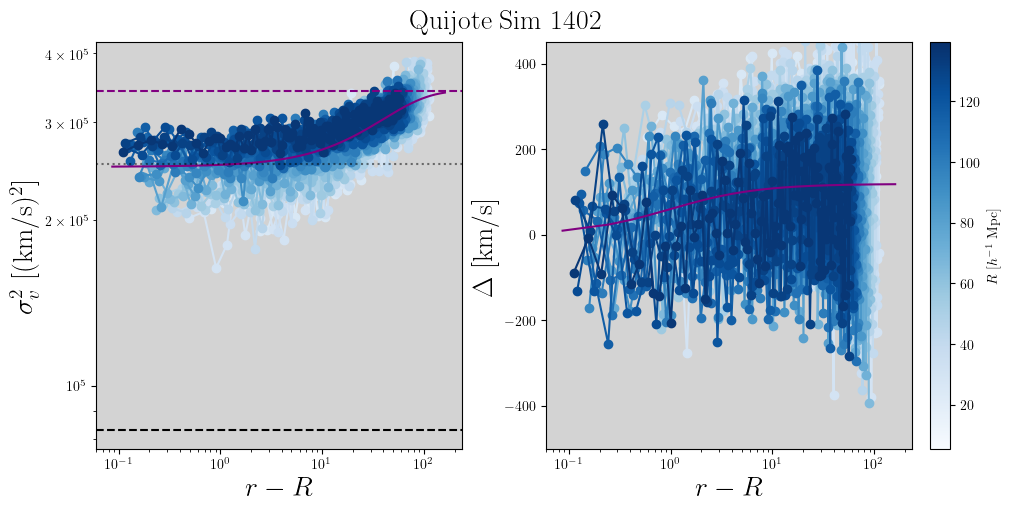

In [28]:
# fit compact functions to \sigma_v, \Delta

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


colormap_list = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens, 
                 plt.cm.Reds, plt.cm.Purples, plt.cm.Greys]

cmaps = [cmap(np.linspace(0, 1, len(r_p))) for cmap in colormap_list]


names = [r'$\sigma_v^2$ [(km/s)$^2$]', r'$\Delta$ [km/s]']

sig_opts = np.full((3), np.nan)
sig_errs = np.full(sig_opts.shape, np.nan)

del_opts = np.full((2), np.nan)
del_errs = np.full(del_opts.shape, np.nan)


skip = 5


A_rho_R = np.full((len(r_p)//skip), np.nan)
A_rho_R_err = np.full(A_rho_R.shape, np.nan)


#sig_rho_fix = sig_opts[:, :, -1]


fig, ax = plt.subplots(1, 2, figsize=(10, 5), layout='constrained', sharex=True)

fig.suptitle(rf"Quijote Sim {sim}", fontsize=20)


mean_vr_interp = interps

Delta = ST_pars[:, :, 0] - mean_vr_interp(r) * r_l / r
com_inputs = [meas_sigv**2, Delta]

smask = np.isfinite(meas_sigv.flatten()) & (meas_sigv.flatten() > 0.1)
dmask = np.isfinite(Delta.flatten()) & (Delta.flatten() > -1000)

# fit models to each input 

popt_sig, sig_cov = curve_fit(lambda x, sig, A, s: sigma_mod(x, sig, A, s), x.flatten()[smask], (meas_sigv).flatten()[smask], p0=[sigma, 0.3, 10], maxfev=5_000, absolute_sigma=False)
popt_del, del_cov = curve_fit(delta_mod, x.flatten()[dmask], Delta.flatten()[dmask], p0=[100, 1], maxfev=5_000, absolute_sigma=False)

# sig_opts = popt_sig
# sig_errs = np.sqrt(np.diag(sig_cov))
# del_opts = popt_del 
# del_errs = np.sqrt(np.diag(del_cov))


xs = np.linspace(x.min()*(1-0.2), x.max()*(1+0.2), 1000)

for j in range(0, len(r_p), skip):
    for i in range(2):

        y = com_inputs[i][j, :]
        
        if i == 0:
            mask = y > 0.1

            # if j == 0:
            #     popt, pcov = curve_fit(lambda x, A: sigma_mod(x, sig_opts[0], A, popt_sig[-1]), x2[:, j], meas_sigv[j, :], p0=popt_sig[1], maxfev=5_000, absolute_sigma=True)
            #     A_rho_R[j//skip] = popt #, sig_rho_fix
            #     A_rho_R_err[j//skip] = np.sqrt(pcov) #[0, 0]

            #     ax[i].plot(xs, sigma_mod(xs, sig_opts[0], popt, popt_sig[-1] )**2, c=cmaps[k][j], ls='--')

            # else:
            #     popt, pcov = curve_fit(lambda x, A: sigma_mod(x, sig_opts[0], A, popt_sig[-1]), x2[:, j], meas_sigv[j, :], p0=popt_sig[1], maxfev=5_000, absolute_sigma=True)

            #     A_rho_R[j//skip] = popt
            #     A_rho_R_err[j//skip] = np.sqrt(pcov)

            #     ax[i].plot(xs, sigma_mod(xs, sig_opts[0], popt, popt_sig[-1] )**2, c=cmaps[k][j], ls='--')

        if i == 1:
            mask = y > -1000

        ax[i].plot(x2[:, j][mask], y[mask], marker='o', c=cmaps[0][j])

        ax[i].set_facecolor('lightgray')
        
        ax[i].set_ylabel(names[i], fontsize=20)
        
        ax[i].set_xscale('log')
        
norm = Normalize(vmin=min(r_p), vmax=max(r_p))
sm = ScalarMappable(norm=norm, cmap=colormap_list[0])
sm.set_array([])  # dummy array
cbar = fig.colorbar(sm, ax=ax[-1])
cbar.set_label(rf"$R \ [h^{{-1}}$ Mpc]", fontsize=10) #$M\in[{massbins[k, 0]:.2e}, {massbins[k, 1]:.2e}] h^{{-1}} M_\odot $

ax[0].plot(xs, sigma_mod(xs, *popt_sig )**2, c='purple') #*popt_sig
#ax[0].set_ylim((140_000, 300_000))
ax[0].set_xscale('log')
ax[0].axhline(2*(sigma)**2, c='k', ls='--')
ax[0].axhline(2*(popt_sig[0])**2, c='purple', ls='--')
ax[0].axhline(2*(355)**2, c='k', ls=':', alpha=0.5)
ax[0].set_yscale('log')

ax[0].set_xlabel(r'$r-R$', fontsize=20)
ax[1].set_xlabel(r'$r-R$', fontsize=20)

ax[1].plot(xs, delta_mod(xs, *popt_del), c='purple')
ax[1].set_ylim((-500, 450))

In [13]:
"""
Compact-model calibration: joint fit of

    sigma_v(x, R) = sqrt( 2 sigma0^2 [ 1 - A_rho(R) exp(-x/sigma_rho) ] )
    A_rho(R)      = A_piv exp( -(R - R_piv)/b )
    Delta(x)      = A_delta x / (sigma_delta + x)

with x = r - R.

Array-shape assumptions (state these before running):
  x, meas_sigv[si,k], Delta   ->  (n_R, n_rlos)
  r_p                         ->  (n_R,)
  x2 in the old code          ==  x.T   (so old x2[:, j]  ->  x[j])
"""

from scipy.optimize import curve_fit
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

SIG_FLOOR = 0.1      # km/s, drop unfit/empty cells
DEL_FLOOR = -1000.0  # km/s


# ---------------------------------------------------------------- models
def sigma_mod(x, sigma0, A_rho, sigma_rho):
    arg = 2.0 * sigma0**2 * (1.0 - A_rho * np.exp(-x / sigma_rho))
    return np.sqrt(np.clip(arg, 1e-8, None))


def A_rho_mod(R, A_piv, b, R_piv):
    return A_piv * np.exp(-(R - R_piv) / b)


def sigma_mod_2d(coords, sigma0, A_piv, b, sigma_rho, R_piv):
    x, R = coords
    return sigma_mod(x, sigma0, A_rho_mod(R, A_piv, b, R_piv), sigma_rho)


def delta_mod(x, A_delta, sigma_delta):
    return A_delta * x / (sigma_delta + x)


# ---------------------------------------------------------------- fitting
def _seed(x, R, sig, R_piv):
    """Linearised seed. With y = 2 sigma0^2 - sigma_v^2,

        log y = log(2 sigma0^2 A_piv) - (R - R_piv)/b - x/sigma_rho

    is linear in (R, x), so an lstsq gives starting values for free."""
    sigma0 = sig.max() / np.sqrt(2.0) * 1.02
    y = 2.0 * sigma0**2 - sig**2
    m = y > 0
    G = np.column_stack([np.ones(m.sum()), -(R[m] - R_piv), -x[m]])
    c = np.linalg.lstsq(G, np.log(y[m]), rcond=None)[0]

    b = 1.0 / c[1] if c[1] > 0 else np.ptp(R) + 1.0
    sigma_rho = 1.0 / c[2] if c[2] > 0 else 10.0
    A_piv = np.clip(np.exp(c[0]) / (2.0 * sigma0**2), 1e-3, 0.99)
    return [sigma0, A_piv, b, sigma_rho]


def fit_sigma_joint(x, r_p, sig, R_piv=None):
    """Single fit for (sigma0, A_piv, b, sigma_rho) using every (R, x) cell."""
    R = np.broadcast_to(r_p[:, None], x.shape)
    m = np.isfinite(x) & np.isfinite(sig) & (sig > SIG_FLOOR)
    X, RR, S = x[m], R[m], sig[m]

    if R_piv is None:
        R_piv = np.median(RR)

    # if np.sum(np.isnan(S)) == len(S.flatten()):
    #     print(sig.min(), m)

    popt, pcov = curve_fit(
        lambda c, s0, Ap, b, sr: sigma_mod_2d(c, s0, Ap, b, sr, R_piv),
        (X, RR), S, p0=_seed(X, RR, S, R_piv),
        bounds=([0.0, 1e-4, 1e-3, 1e-3], [np.inf, 1.0, np.inf, np.inf]),
        maxfev=20_000,
    )
    perr = np.sqrt(np.diag(pcov))
    corr = pcov / np.outer(perr, perr)
    return popt, perr, corr, R_piv


def fit_A_per_R(x, sig, sigma0, sigma_rho):
    """Old per-R_perp fit, kept as a diagnostic: is A_rho(R) really exponential?"""
    A = np.full(x.shape[0], np.nan)
    Aerr = np.full(x.shape[0], np.nan)
    for j in range(x.shape[0]):
        m = np.isfinite(x[j]) & np.isfinite(sig[j]) & (sig[j] > SIG_FLOOR)
        if m.sum() < 3:
            continue
        p, c = curve_fit(lambda xx, a: sigma_mod(xx, sigma0, a, sigma_rho),
                         x[j][m], sig[j][m], p0=[0.3],
                         bounds=(1e-4, 1.0), maxfev=10_000)
        A[j], Aerr[j] = p[0], np.sqrt(c[0, 0])
    return A, Aerr


def fit_delta(x, D):
    m = np.isfinite(x) & np.isfinite(D) & (D > DEL_FLOOR)
    popt, pcov = curve_fit(delta_mod, x[m], D[m], p0=[100.0, 1.0], maxfev=10_000)
    return popt, np.sqrt(np.diag(pcov))


# ---------------------------------------------------------------- driver
colormap_list = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens,
                 plt.cm.Reds, plt.cm.Purples, plt.cm.Greys]
names = [r'$\sigma_v^2$ [(km/s)$^2$]', r'$\Delta$ [km/s]']

n_sim, n_R = len(SIMS), len(r_p)

sig_opts = np.full((n_sim, 4), np.nan)   # sigma0, A_piv, b, sigma_rho
sig_errs = np.full_like(sig_opts, np.nan) 
sig_corr = np.full((n_sim, 4, 4), np.nan)
R_pivs   = np.full((n_sim), np.nan)
del_opts = np.full((n_sim, 2), np.nan)
del_errs = np.full_like(del_opts, np.nan)
A_rho_R     = np.full((n_sim, n_R), np.nan)
A_rho_R_err = np.full_like(A_rho_R, np.nan)

skip = 5   # plotting stride only; the fits use every R bin
xs = np.linspace(x.min() * 0.8, x.max() * 1.2, 1000)

for si, sim in tqdm(enumerate(SIMS)):
    # fig, ax = plt.subplots(n_M, 3, figsize=(15, 5 * n_M),
    #                        layout='constrained', sharex='col')
    # fig.suptitle(rf"c_000_ph{sim}", fontsize=20)
    cmap_k = colormap_list[si % len(colormap_list)]

    for k in range(1):
        sig = meas_sigv[si]
        Delta = ST_pars[si, :, :, 0] - sim_interps[si](r) * r_l / r

        if np.isnan(sig).all() or np.isnan(Delta).all():
            continue

        # --- fits -------------------------------------------------------
        popt, perr, corr, R_piv = fit_sigma_joint(x, r_p, sig)
        sig_opts[si], sig_errs[si], sig_corr[si] = popt, perr, corr
        R_pivs[si] = R_piv
        del_opts[si], del_errs[si] = fit_delta(x, Delta)

        A_rho_R[si], A_rho_R_err[si] = fit_A_per_R(x, sig, popt[0], popt[3])

   # ---------------------------------------------------------------- driver
colormap_list = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens,
                 plt.cm.Reds, plt.cm.Purples, plt.cm.Greys]
names = [r'$\sigma_v^2$ [(km/s)$^2$]', r'$\Delta$ [km/s]']

PLOT_DIR = 'diagnostic_plots'
os.makedirs(PLOT_DIR, exist_ok=True)

n_sim, n_R = len(SIMS), len(r_p)
n_M = 1   # single mass bin, matches `for k in range(1)` below

sig_opts = np.full((n_sim, 4), np.nan)   # sigma0, A_piv, b, sigma_rho
sig_errs = np.full_like(sig_opts, np.nan)
sig_corr = np.full((n_sim, 4, 4), np.nan)
R_pivs   = np.full((n_sim), np.nan)
del_opts = np.full((n_sim, 2), np.nan)
del_errs = np.full_like(del_opts, np.nan)
A_rho_R     = np.full((n_sim, n_R), np.nan)
A_rho_R_err = np.full_like(A_rho_R, np.nan)

skip = 5   # plotting stride only; the fits use every R bin
xs = np.linspace(x.min() * 0.8, x.max() * 1.2, 1000)

for si, sim in tqdm(enumerate(SIMS)):
    cmap_k = colormap_list[si % len(colormap_list)]

    fig, ax = plt.subplots(n_M, 3, figsize=(15, 5 * n_M),
                           layout='constrained', sharex='col', squeeze=False)
    fig.suptitle(rf"{sim}", fontsize=20)

    drew = False

    for k in range(1):
        sig = meas_sigv[si]
        Delta = ST_pars[si, :, :, 0] - sim_interps[si](r) * r_l / r

        if np.isnan(sig).all() or np.isnan(Delta).all():
            continue

        # --- fits -------------------------------------------------------
        popt, perr, corr, R_piv = fit_sigma_joint(x, r_p, sig)
        sig_opts[si], sig_errs[si], sig_corr[si] = popt, perr, corr
        R_pivs[si] = R_piv
        del_opts[si], del_errs[si] = fit_delta(x, Delta)

        A_rho_R[si], A_rho_R_err[si] = fit_A_per_R(x, sig, popt[0], popt[3])
        drew = True

        # --- panel 0: sigma_v^2 vs x, one curve per R -------------------
        colors = cmap_k(np.linspace(0.3, 1, n_R))
        for j in range(0, n_R, skip):
            m = sig[j] > SIG_FLOOR
            ax[k, 0].plot(x[j][m], sig[j][m]**2, 'o', c=colors[j])
            ax[k, 0].plot(xs, sigma_mod(xs, popt[0],
                                        A_rho_mod(r_p[j], popt[1], popt[2], R_piv),
                                        popt[3])**2, c=colors[j], ls='--')
        ax[k, 0].axhline(2 * popt[0]**2, c='purple', ls='--')
        ax[k, 0].axhline(2 * 355.0**2, c='k', ls=':', alpha=0.5)
        ax[k, 0].set(xscale='log', yscale='log', ylim=(140_000, 300_000),
                     ylabel=names[0])

        # --- panel 1: Delta --------------------------------------------
        for j in range(0, n_R, skip):
            m = Delta[j] > DEL_FLOOR
            ax[k, 1].plot(x[j][m], Delta[j][m], 'o', c=colors[j])
        ax[k, 1].plot(xs, delta_mod(xs, *del_opts[si]), c='purple')
        ax[k, 1].set(xscale='log', ylim=(-500, 450), ylabel=names[1])

        # --- panel 2: A_rho(R), joint fit vs per-bin --------------------
        ax[k, 2].errorbar(r_p, A_rho_R[si], A_rho_R_err[si],
                          fmt='o', c='k', ms=3, label='per-$R$ fit')
        ax[k, 2].plot(r_p, A_rho_mod(r_p, popt[1], popt[2], R_piv),
                      c='purple', label='joint exp. fit')
        ax[k, 2].set(xlabel=r'$R\ [h^{-1}$ Mpc]', ylabel=r'$A_\rho$')
        ax[k, 2].legend(fontsize=8)

        sm = ScalarMappable(norm=Normalize(vmin=r_p.min(), vmax=r_p.max()), cmap=cmap_k)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax[k, 1])
        cbar.set_label(rf"$R\ [h^{{-1}}$ Mpc]", fontsize=10)

        # print(f"ph{sim} k={k}: sigma0={popt[0]:.1f}+-{perr[0]:.1f}  "
        #       f"A_piv={popt[1]:.3f}+-{perr[1]:.3f}  b={popt[2]:.2f}+-{perr[2]:.2f}  "
        #       f"sigma_rho={popt[3]:.2f}+-{perr[3]:.2f}  "
        #       f"| corr(A,b)={corr[1,2]:+.2f} corr(b,s_rho)={corr[2,3]:+.2f} "
        #       f"corr(s0,A)={corr[0,1]:+.2f}  A(R_min)={A_rho_mod(r_p.min(), *popt[1:3], R_piv):.3f}")

    if drew:
        for i in range(2):
            ax[-1, i].set_xlabel(r'$r-R$', fontsize=20)
        fig.savefig(os.path.join(PLOT_DIR, f'compact_fit_{sim}.png'), dpi=120)

    plt.close(fig)

100it [00:31,  3.15it/s]
100it [02:38,  1.58s/it]


In [41]:
sig_opts.shape

(100, 4)

In [52]:
print(cosmos[0])

Cosmology "myCosmo" 
    flat = True, Om0 = 0.2477, Ode0 = 0.7522, Ob0 = 0.0561, H0 = 55.07, sigma8 = 0.9721, ns = 1.1205
    de_model = lambda, relspecies = True, Tcmb0 = 2.7255, Neff = 3.0460, powerlaw = False


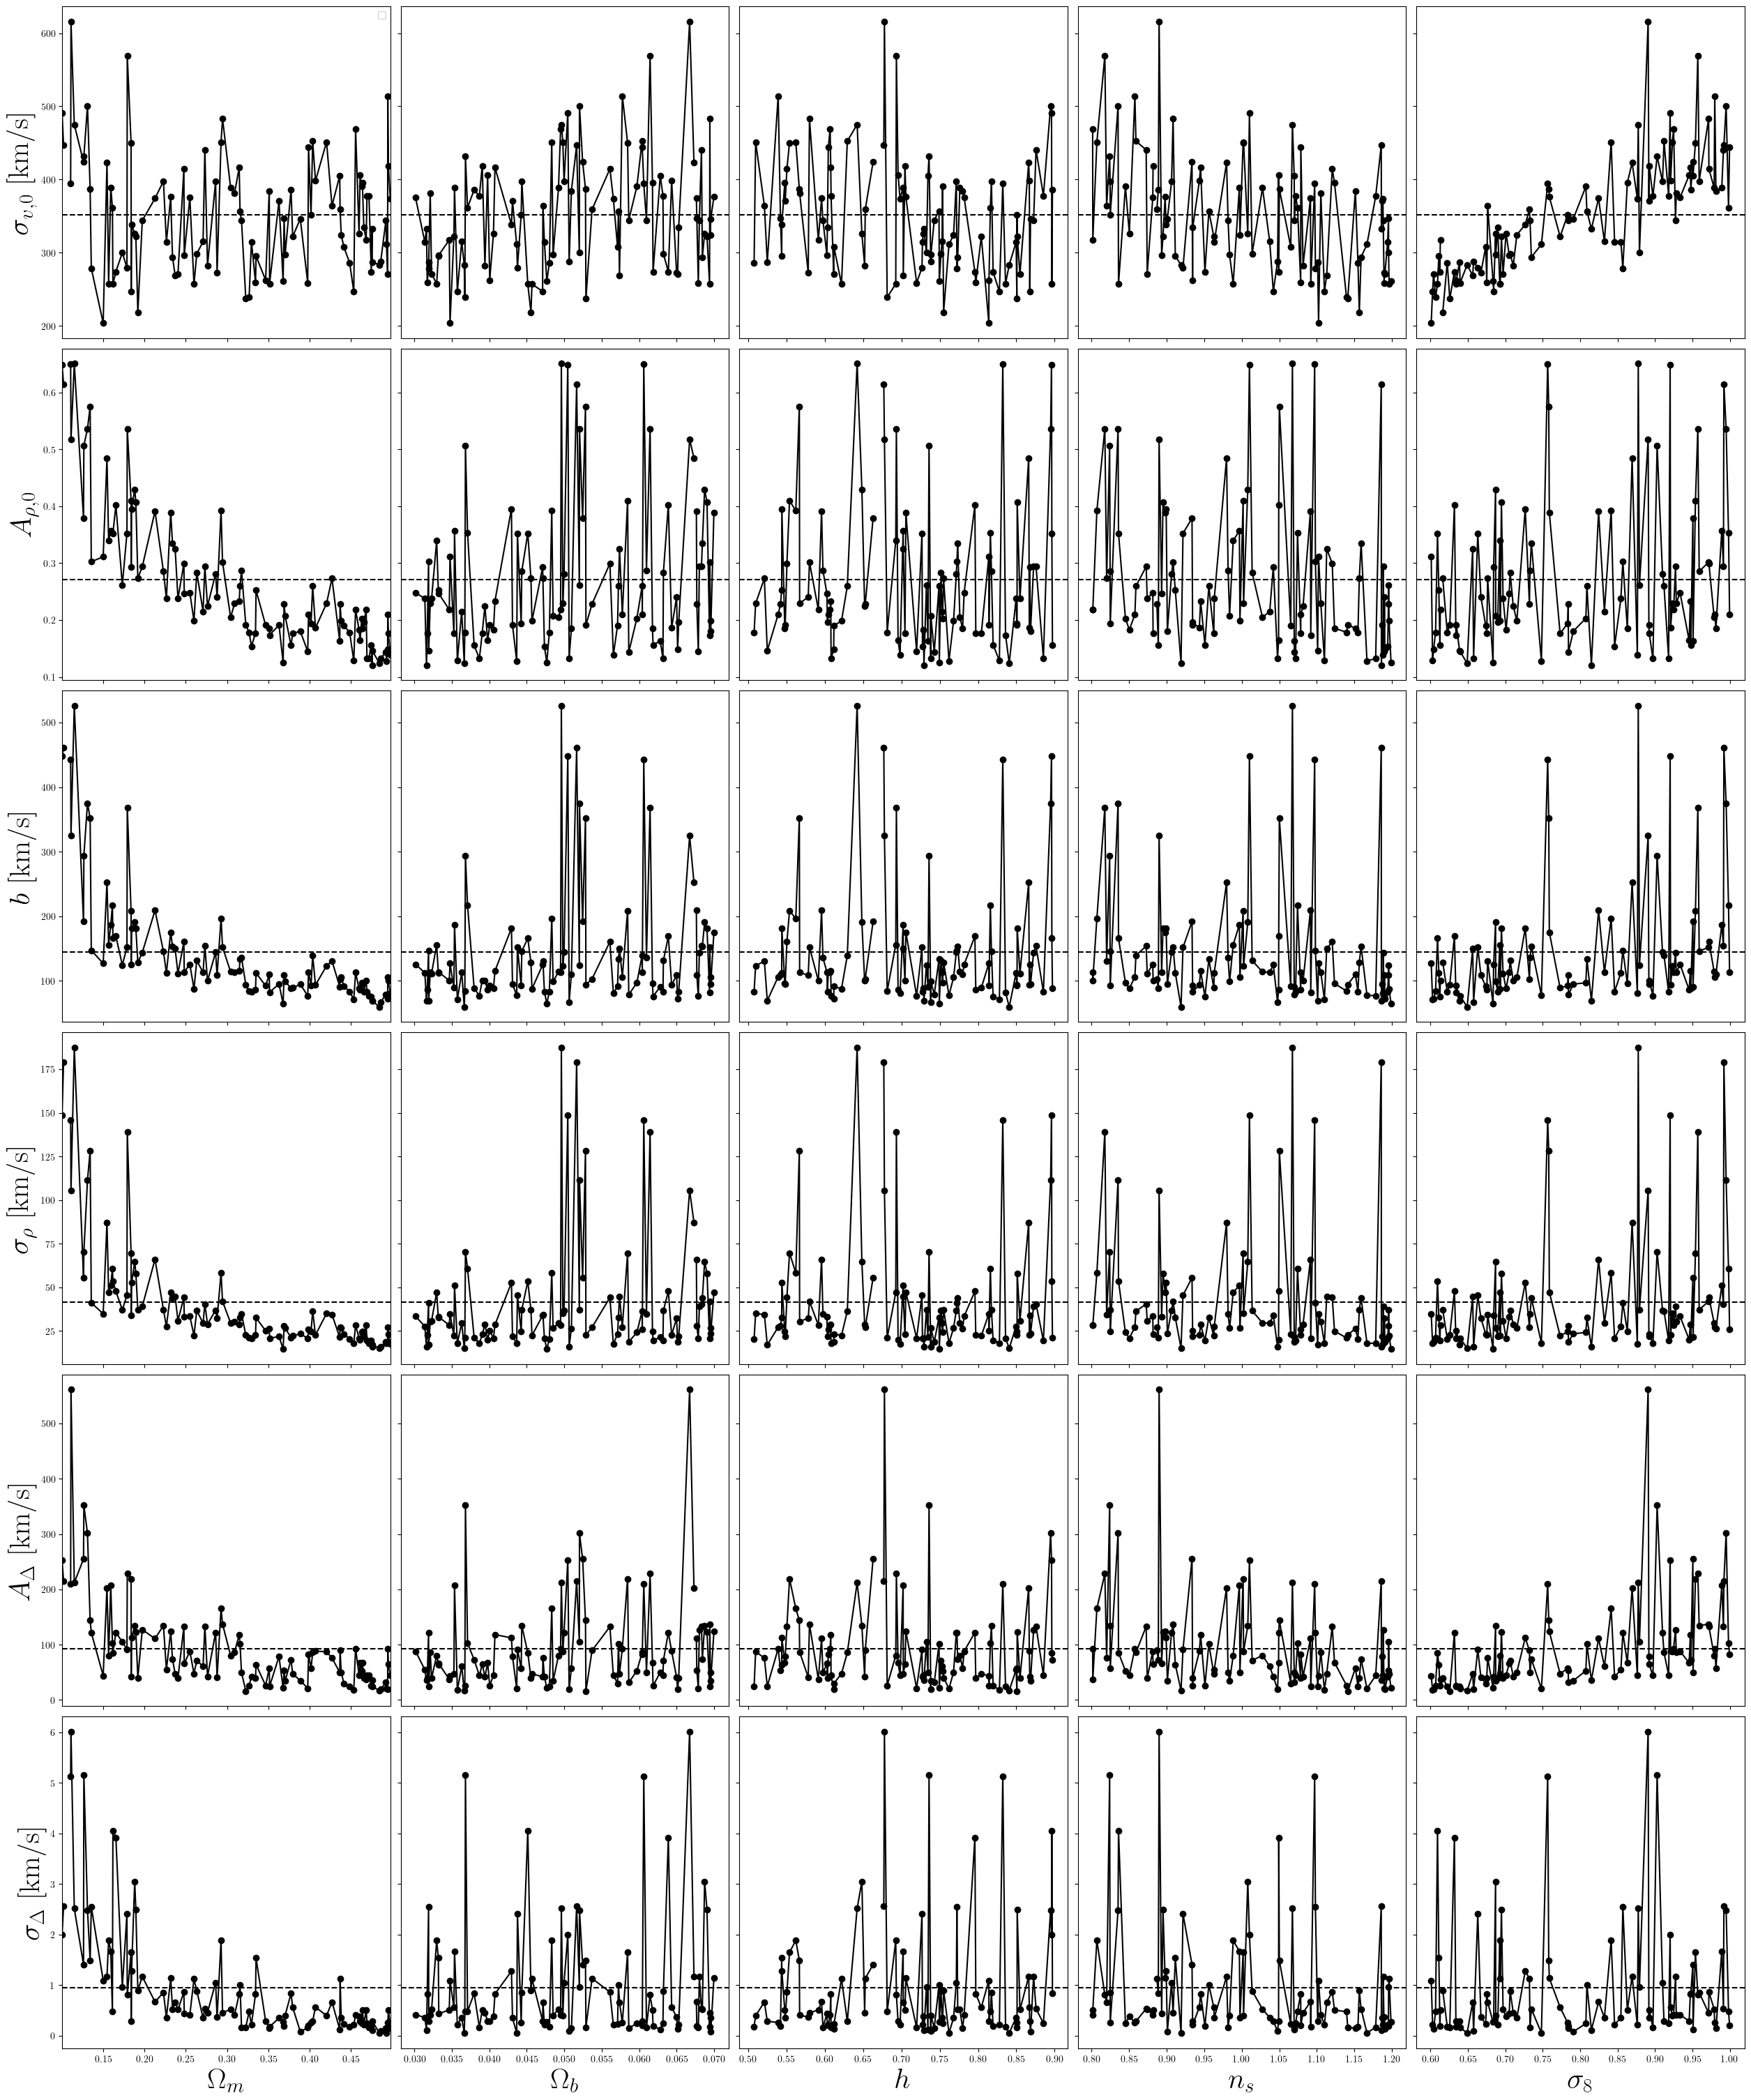

In [ ]:
fig, ax = plt.subplots(6, 5, figsize=(25, 30), sharex='col', sharey='row', layout='constrained')

fixed_parameters = np.concatenate(([355], sig_pars, del_pars))
parameters = np.concatenate((sig_opts, del_opts), axis=-1)
errors = np.concatenate((sig_errs, del_errs), axis=-1)

labels = [r"$\sigma_{v, 0}$ [km/s]", r"$A_{\rho, 0}$", r"$b$ [km/s]", r"$\sigma_\rho$ [km/s]", r"$A_\Delta$ [km/s]", r"$\sigma_\Delta$ [km/s]"]

c_labels = [r"$\Omega_m$", r"$\Omega_b$", r"$h$", r"$n_s$", r"$\sigma_8$"]

for i in range(len(labels)):
    for j in range(len(c_labels)):
        x_plot = cosmo_arr[:, j]
        order = np.argsort(x_plot)
        ax[i, j].plot(x_plot[order], parameters[order, i], marker='o', c='k')
        ax[i, j].axhline(np.nanmean(parameters[order, i]), c='k', ls='--')
        
        #ax[i, j].axhline(fixed_parameters[i], c='k', ls='--', label=r'MDPL2 fit')
        ax[-1, j].set_xlabel(c_labels[j], fontsize=30)
        ax[i, k].margins(x=0)

    ax[i, 0].set_ylabel(labels[i], fontsize=30)a

ax[0, 0].legend(fontsize=10)


In [15]:
parameters.shape

(100, 6)

In [17]:
cosmo_arr.shape

(100, 5)

In [18]:
cosmo_arr[0]

array([0.2477 , 0.05609, 0.5507 , 1.1205 , 0.9721 ])

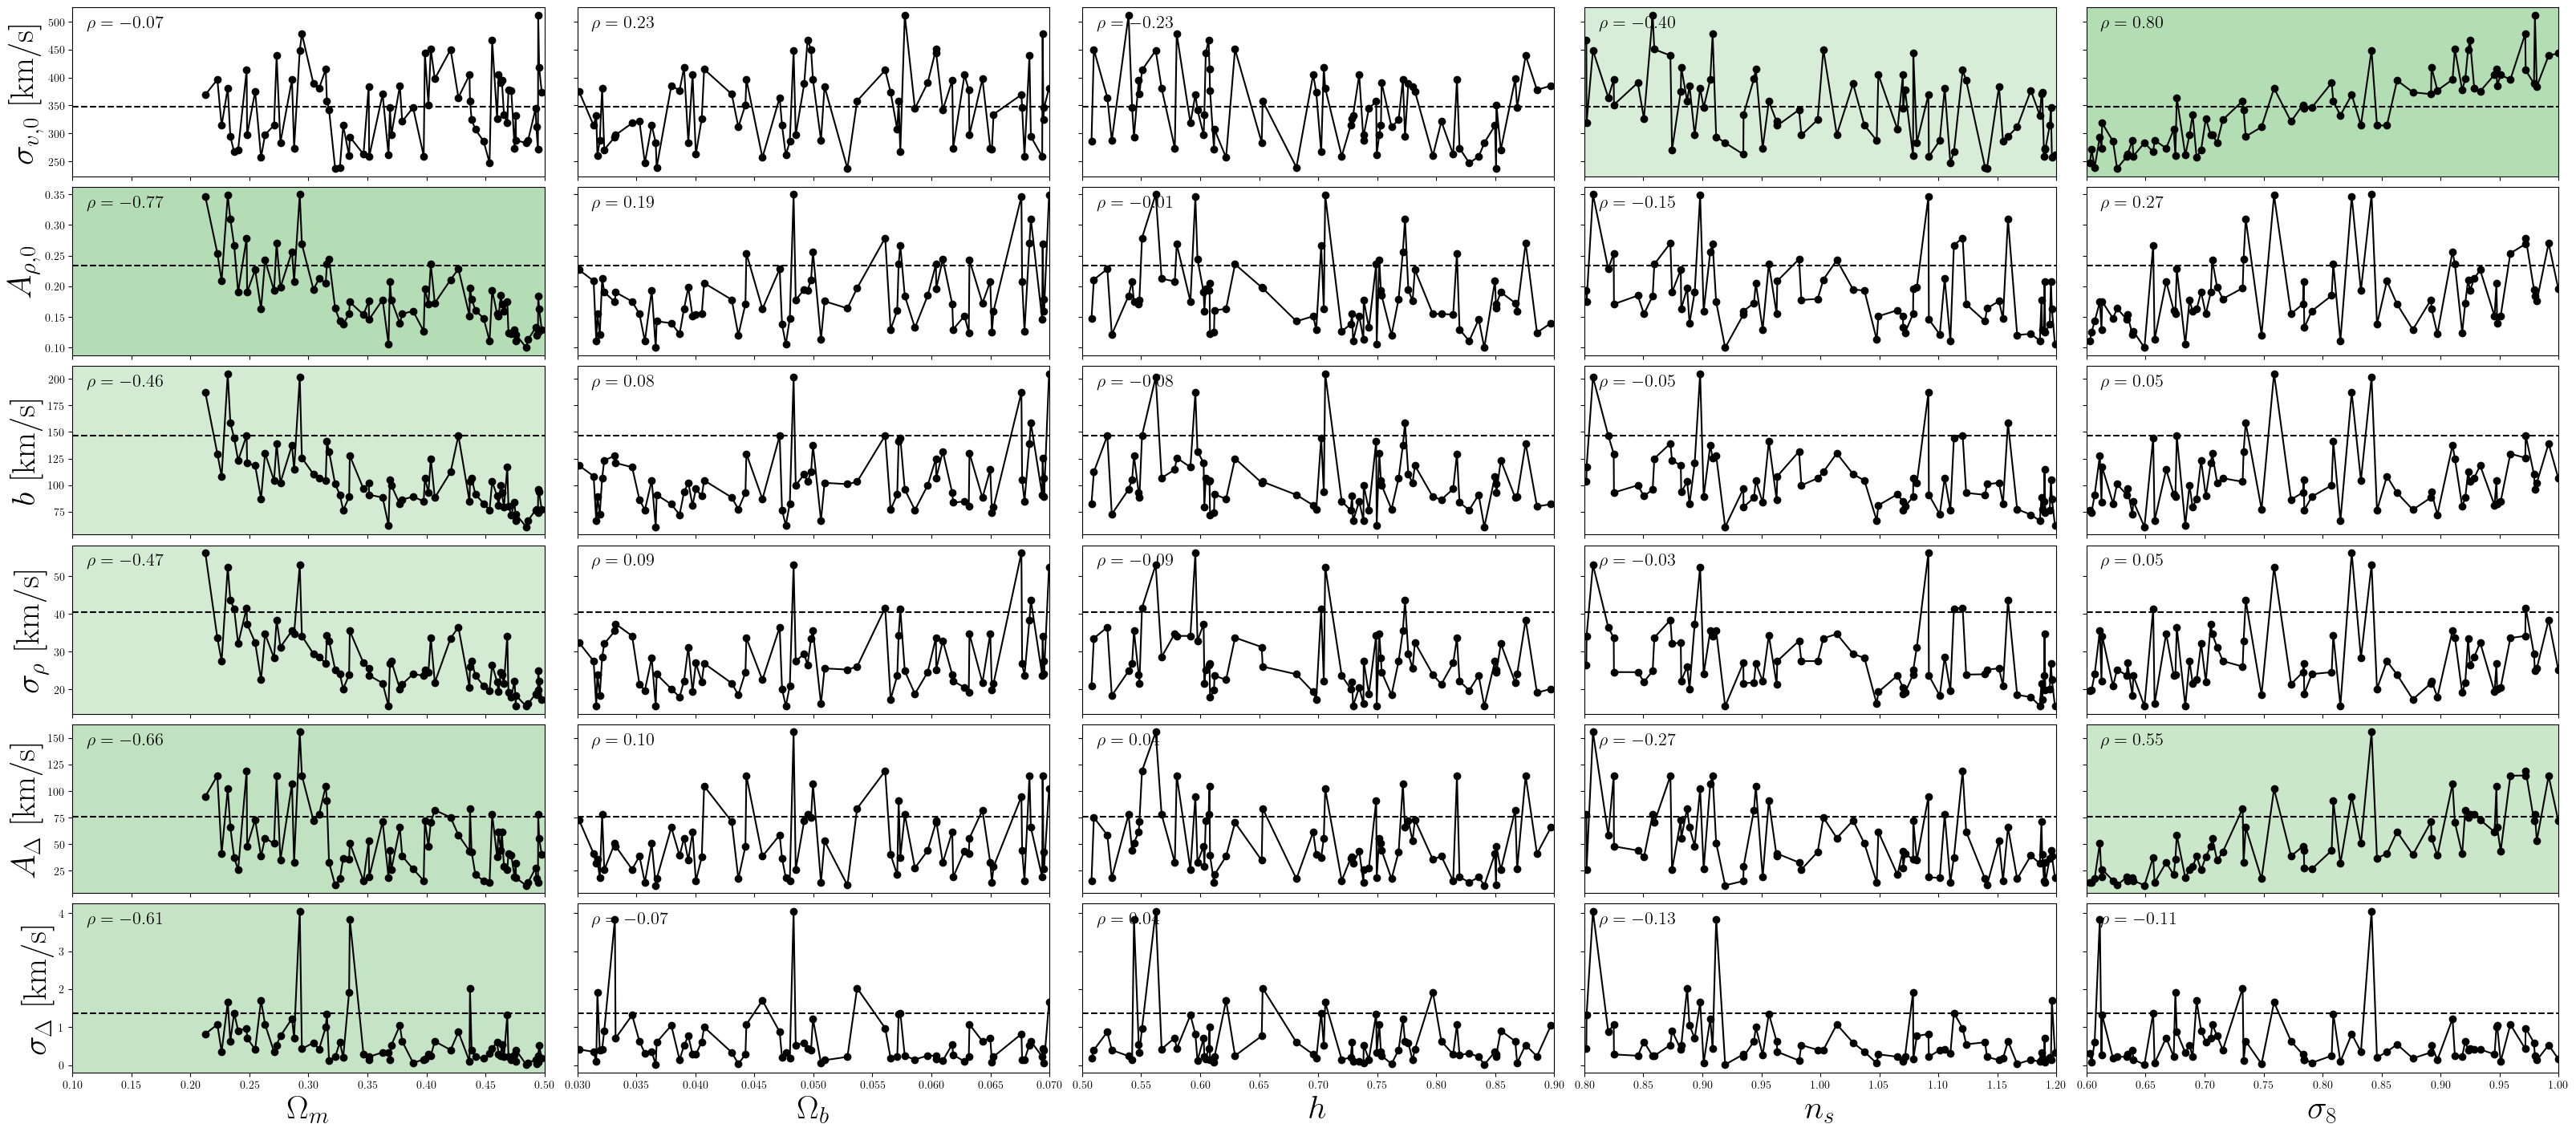

In [31]:
from scipy.stats import spearmanr, pearsonr
from matplotlib.colors import to_rgba

scale = 2
fig, ax = plt.subplots(6, 5, figsize=(16*scale, 7*scale), sharex='col', sharey='row', layout='constrained')

fixed_parameters = np.concatenate(([355], sig_pars, del_pars))
parameters = np.concatenate((sig_opts, del_opts), axis=-1)
errors = np.concatenate((sig_errs, del_errs), axis=-1)

labels = [r"$\sigma_{v, 0}$ [km/s]", r"$A_{\rho, 0}$", r"$b$ [km/s]", r"$\sigma_\rho$ [km/s]", r"$A_\Delta$ [km/s]", r"$\sigma_\Delta$ [km/s]"]

c_labels = [r"$\Omega_m$", r"$\Omega_b$", r"$h$", r"$n_s$", r"$\sigma_8$"]

lims = [[0.1, 0.5], [0.03, 0.07], [0.5, 0.9], [0.8, 1.2], [0.6, 1.0]]

ylims = [[190, 620], [0.1, 0.7], [0, 550], [0, 200], [0, 600], [0, 6.2]]

RHO_MIN = 0.0
P_MAX = 0.05 / (len(labels) * len(c_labels))
ALPHA_MAX = 0.45

for i in range(len(labels)):
    for j in range(len(c_labels)):
        x_plot = cosmo_arr[:, j]
        order = np.argsort(x_plot)

        mask = cosmo_arr[order, 0] > 0.2
        ax[i, j].plot(x_plot[order][mask], parameters[order, i][mask], marker='o', c='k')
        ax[i, j].axhline(np.nanmean(parameters[order, i]), c='k', ls='--')

        good = np.isfinite(parameters[:, i])
        rho, p = pearsonr(x_plot[good], parameters[good, i])
        dependent = (abs(rho) >= RHO_MIN) and (p < P_MAX)
        alpha = ALPHA_MAX * min(abs(rho), 1.0)
        ax[i, j].set_facecolor(to_rgba('tab:green' if dependent else 'tab:red', alpha if dependent else 0.0))
        ax[i, j].text(0.03, 0.95, rf'$\rho={rho:.2f}$', transform=ax[i, j].transAxes,
                      va='top', fontsize=16)

        ax[-1, j].set_xlabel(c_labels[j], fontsize=30)
        #ax[i, j].margins(x=0)
        ax[i, j].set_xlim(lims[j])
        #ax[i, j].set_ylim(ylims[i])

    ax[i, 0].set_ylabel(labels[i], fontsize=30)

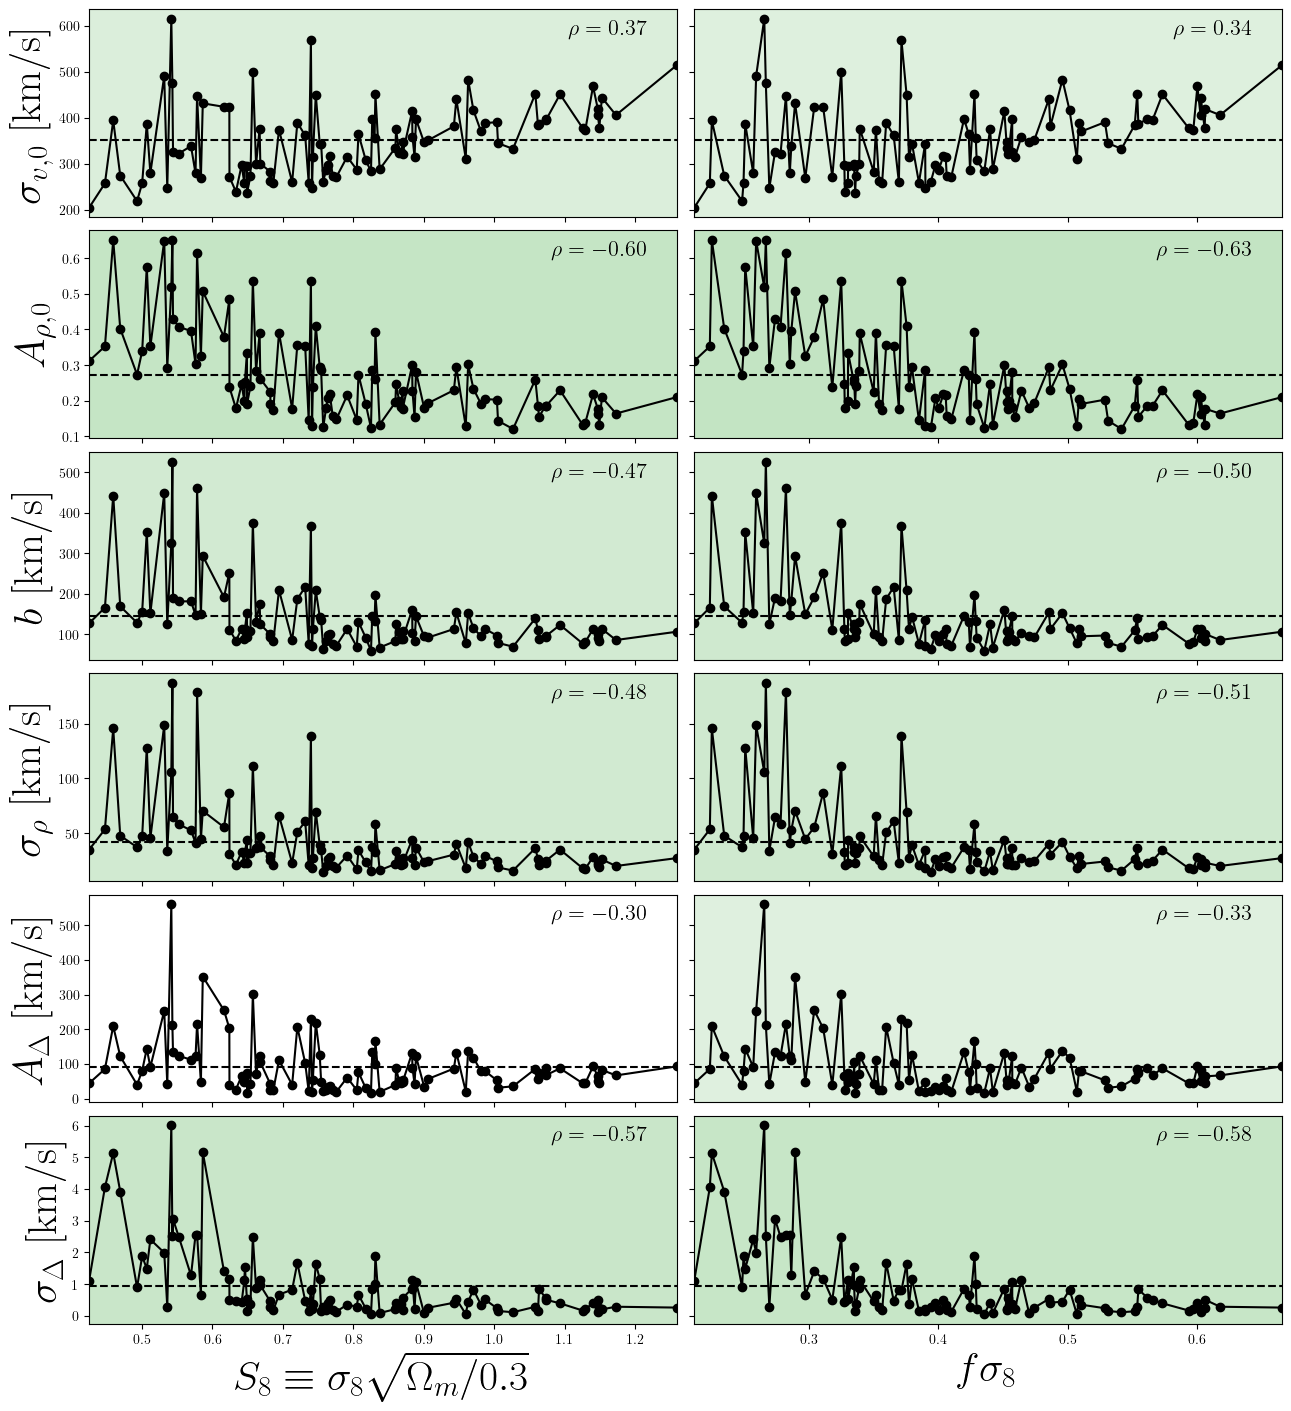

In [92]:
from matplotlib.colors import to_rgba

Z_SIM = 0.0
GAMMA = 0.55

Om, s8 = cosmo_arr[:, 0], cosmo_arr[:, 4]
S8 = s8 * np.sqrt(Om / 0.3)
fs8 = np.array([c.Om(Z_SIM)**GAMMA * s8[k] * c.growthFactor(Z_SIM)
                for k, c in enumerate(cosmos)])

derived = np.column_stack((S8, fs8))
d_labels = [r"$S_8 \equiv \sigma_8\sqrt{\Omega_m/0.3}$", rf"$f\sigma_8$"]

fig, ax = plt.subplots(6, 2, figsize=(16*scale*2/5, 7*scale), sharex='col', sharey='row', layout='constrained')

parameters = np.concatenate((sig_opts, del_opts), axis=-1)

labels = [r"$\sigma_{v, 0}$ [km/s]", r"$A_{\rho, 0}$", r"$b$ [km/s]", r"$\sigma_\rho$ [km/s]", r"$A_\Delta$ [km/s]", r"$\sigma_\Delta$ [km/s]"]

RHO_MIN = 0.3
P_MAX = 0.05 / (len(labels) * len(d_labels))
ALPHA_MAX = 0.45

for i in range(len(labels)):
    for j in range(len(d_labels)):
        x_plot = derived[:, j]
        order = np.argsort(x_plot)
        ax[i, j].plot(x_plot[order], parameters[order, i], marker='o', c='k')
        ax[i, j].axhline(np.nanmean(parameters[:, i]), c='k', ls='--')

        good = np.isfinite(parameters[:, i])
        rho, p = pearsonr(x_plot[good], parameters[good, i])
        dependent = (abs(rho) >= RHO_MIN) and (p < P_MAX)
        alpha = ALPHA_MAX * min(abs(rho), 1.0)
        ax[i, j].set_facecolor(to_rgba('tab:green' if dependent else 'tab:red', alpha if dependent else 0.0))
        ax[i, j].text(0.95, 0.95, rf'$\rho={rho:.2f}$', transform=ax[i, j].transAxes,
                      va='top', ha='right', fontsize=16)

        ax[-1, j].set_xlabel(d_labels[j], fontsize=30)
        ax[i, j].margins(x=0)

    ax[i, 0].set_ylabel(labels[i], fontsize=30)

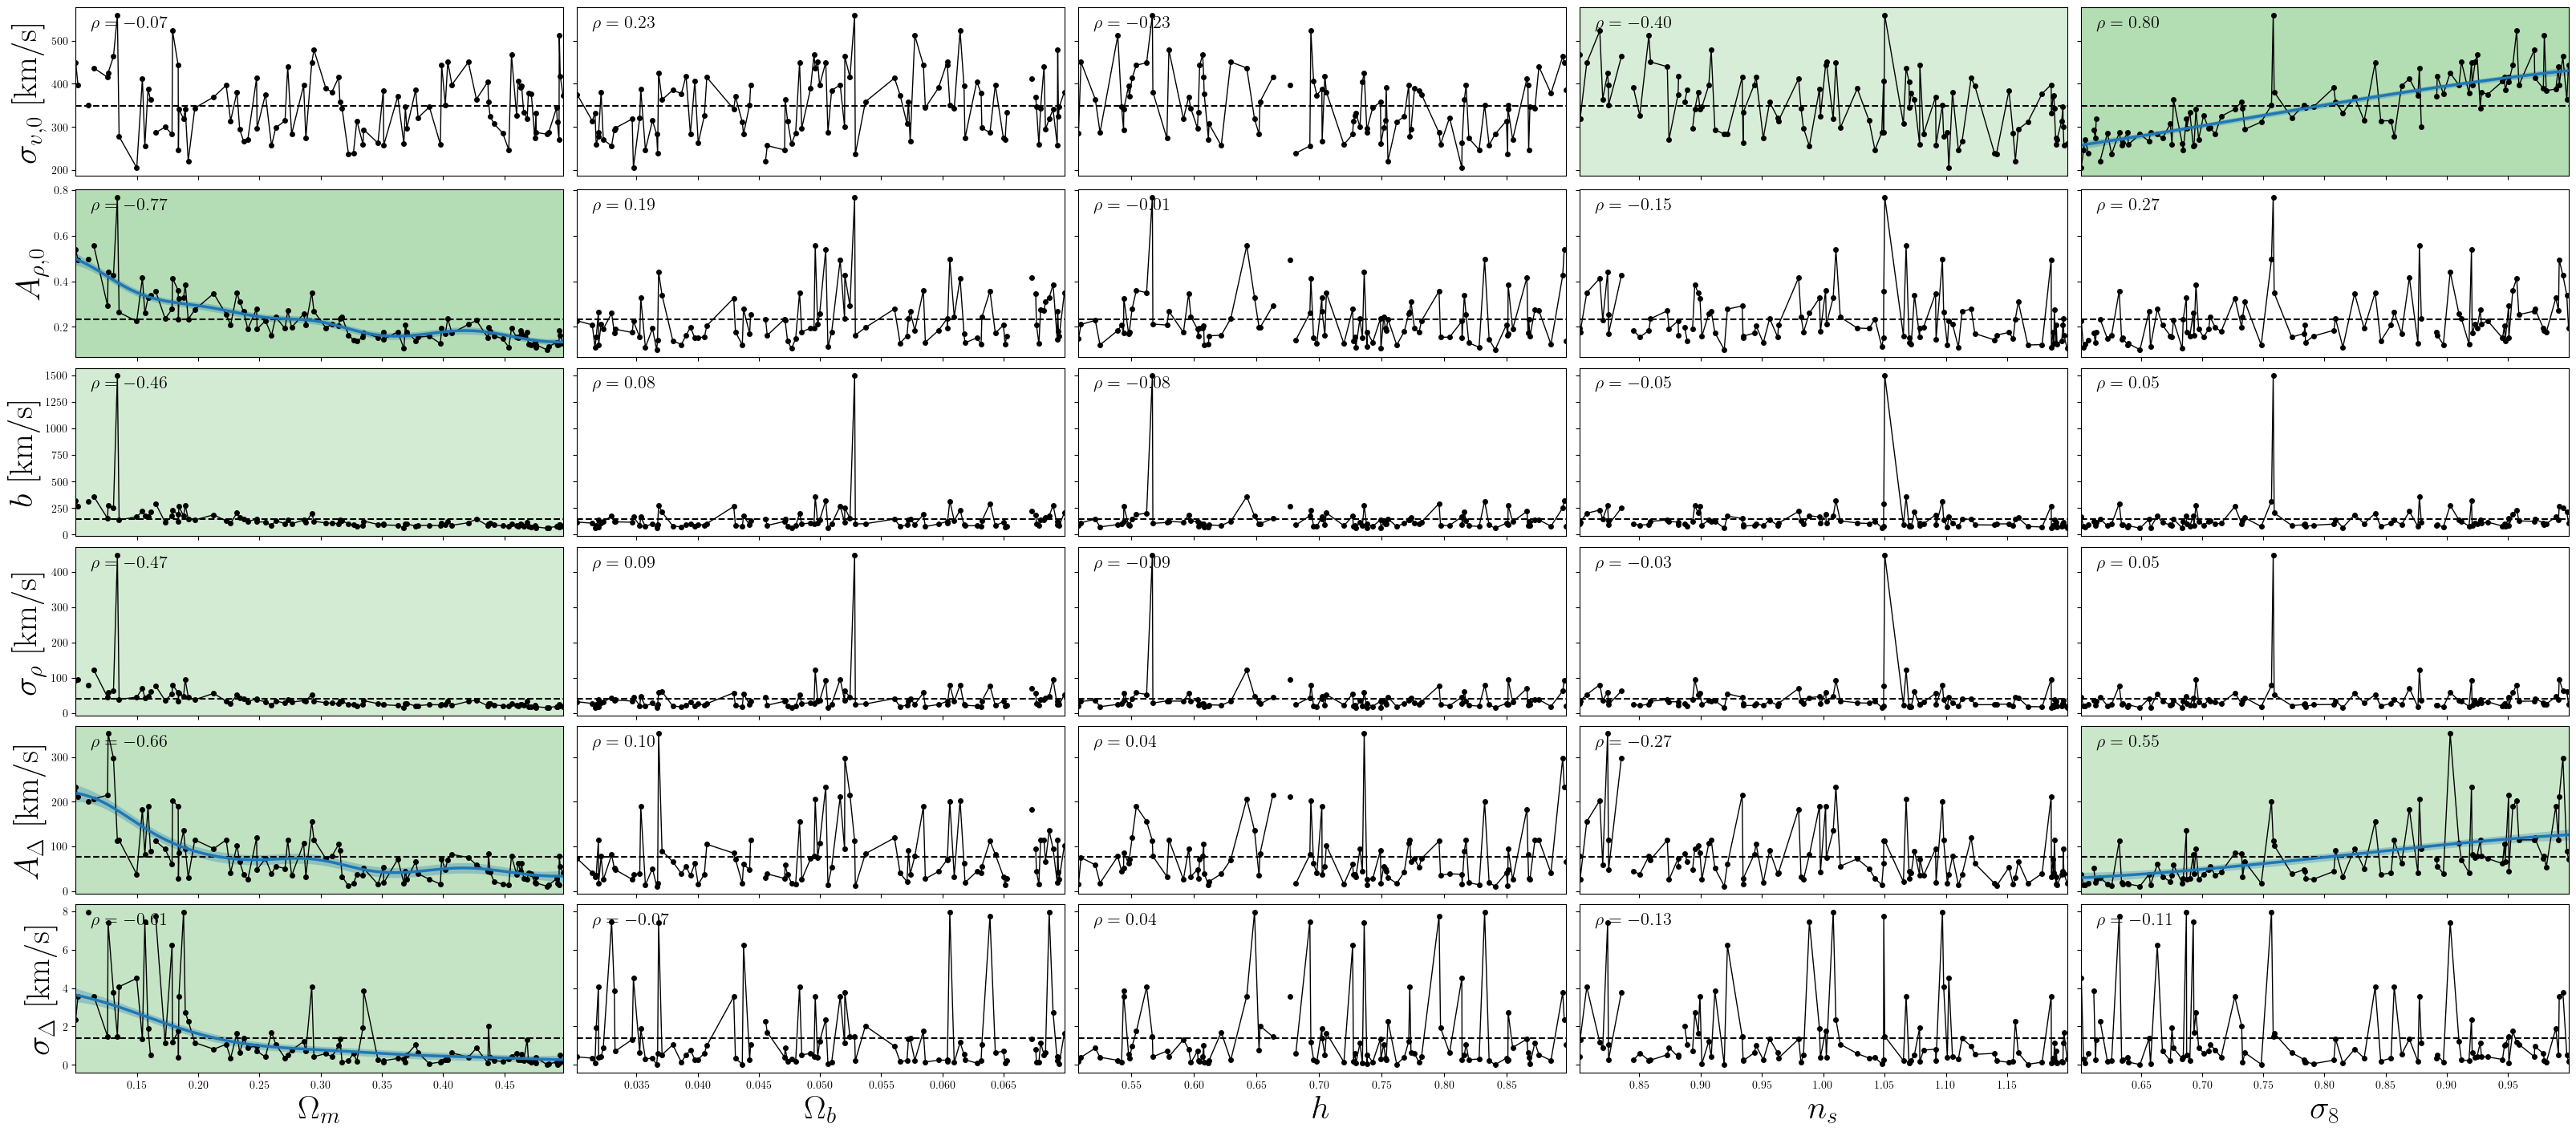

In [24]:
import numpy as np
import h5py
import george
from george import kernels
from scipy.optimize import minimize
from scipy.stats import spearmanr
from matplotlib.colors import to_rgba


def fit_panel_gp(x, y, yerr, n_restarts=3, seed=0):
    """1D george GP on standardized data. Returns a serializable record, or None."""
    x_mu, x_sd = x.mean(), x.std()
    y_mu, y_sd = y.mean(), y.std()
    xs, ys, es = (x - x_mu) / x_sd, (y - y_mu) / y_sd, yerr / y_sd

    kernel = np.var(ys) * kernels.Matern52Kernel(metric=1.0)
    gp = george.GP(kernel, white_noise=np.log(1e-2), fit_white_noise=True)
    gp.compute(xs, es)

    def nll(p):
        gp.set_parameter_vector(p)
        ll = gp.log_likelihood(ys, quiet=True)
        return -ll if np.isfinite(ll) else 1e25

    def grad_nll(p):
        gp.set_parameter_vector(p)
        return -gp.grad_log_likelihood(ys, quiet=True)

    rng = np.random.default_rng(seed)
    p0 = gp.get_parameter_vector()
    best = None
    for k in range(n_restarts):
        start = p0 if k == 0 else p0 + rng.normal(0, 1.0, size=p0.size)
        try:
            soln = minimize(nll, start, jac=grad_nll, method='L-BFGS-B')
        except (ValueError, np.linalg.LinAlgError):
            continue
        if soln.success and (best is None or soln.fun < best.fun):
            best = soln
    if best is None:
        return None

    return dict(pvec=best.x, xs=xs, ys=ys, es=es,
                x_mu=x_mu, x_sd=x_sd, y_mu=y_mu, y_sd=y_sd)


def gp_predict(rec, x_new):
    """Rebuild the GP from a record and predict in native units -> (mu, sd)."""
    kernel = np.var(rec['ys']) * kernels.Matern52Kernel(metric=1.0)
    gp = george.GP(kernel, white_noise=np.log(1e-2), fit_white_noise=True)
    gp.set_parameter_vector(rec['pvec'])
    gp.compute(rec['xs'], rec['es'])

    xn = (np.atleast_1d(x_new) - rec['x_mu']) / rec['x_sd']
    mu, var = gp.predict(rec['ys'], xn, return_var=True)
    return mu * rec['y_sd'] + rec['y_mu'], np.sqrt(np.maximum(var, 0)) * rec['y_sd']


fig, ax = plt.subplots(6, 5, figsize=(16*scale, 7*scale), sharex='col', sharey='row', layout='constrained')

parameters = np.concatenate((sig_opts, del_opts), axis=-1)
errors = np.concatenate((sig_errs, del_errs), axis=-1)

labels = [r"$\sigma_{v, 0}$ [km/s]", r"$A_{\rho, 0}$", r"$b$ [km/s]", r"$\sigma_\rho$ [km/s]", r"$A_\Delta$ [km/s]", r"$\sigma_\Delta$ [km/s]"]
c_labels = [r"$\Omega_m$", r"$\Omega_b$", r"$h$", r"$n_s$", r"$\sigma_8$"]
c_names = ['Om', 'Ob', 'h', 'ns', 's8']
p_names = ['sig_v0', 'A_rho0', 'b', 'sig_rho', 'A_Del', 'sig_Del']

RHO_MIN = 0.3
RHO_FIT = 0.5
P_MAX = 0.05 / (len(labels) * len(c_labels))
ALPHA_MAX = 0.45

records = {}

for i in range(len(labels)):
    for j in range(len(c_labels)):
        x_plot = cosmo_arr[:, j]
        order = np.argsort(x_plot)
        ax[i, j].plot(x_plot[order], parameters[order, i], marker='o', c='k', lw=1, ms=4)
        ax[i, j].axhline(np.nanmean(parameters[:, i]), c='k', ls='--')

        good = np.isfinite(parameters[:, i]) & np.isfinite(errors[:, i]) & (errors[:, i] > 0)
        rho, p = pearsonr(x_plot[good], parameters[good, i])
        dependent = (abs(rho) >= RHO_MIN) and (p < P_MAX)
        ax[i, j].set_facecolor(to_rgba('tab:green' if dependent else 'tab:red',
                                       ALPHA_MAX * min(abs(rho) if dependent else 0.0, 1.0)))

        if abs(rho) >= RHO_FIT and good.sum() > 10:
            rec = fit_panel_gp(x_plot[good], parameters[good, i], errors[good, i])
            if rec is not None:
                rec['rho'] = rho
                records[(p_names[i], c_names[j])] = rec
                xg = np.linspace(x_plot[good].min(), x_plot[good].max(), 200)
                mu, sd = gp_predict(rec, xg)
                ax[i, j].fill_between(xg, mu - sd, mu + sd, color='tab:blue', alpha=0.3, lw=0)
                ax[i, j].plot(xg, mu, c='tab:blue', lw=2.5)

        ax[i, j].text(0.03, 0.95, rf'$\rho={rho:.2f}$', transform=ax[i, j].transAxes,
                      va='top', fontsize=16)
        ax[-1, j].set_xlabel(c_labels[j], fontsize=30)
        ax[i, j].margins(x=0)

    ax[i, 0].set_ylabel(labels[i], fontsize=30)


# GP_PATH = '/spiffball/cosweeney/simulations/Quijote/halos/latin_hypercube_HR/data/compact_gps.h5'

# with h5py.File(GP_PATH, 'w') as f:
#     f.attrs['kernel'] = 'Matern52'
#     f.attrs['basis'] = 'quijote'
#     f.attrs['n_sims'] = len(SIMS)
#     for (pname, cname), rec in records.items():
#         g = f.create_group(f'{pname}/{cname}')
#         for key in ('pvec', 'xs', 'ys', 'es'):
#             g.create_dataset(key, data=rec[key])
#         for key in ('x_mu', 'x_sd', 'y_mu', 'y_sd', 'rho'):
#             g.attrs[key] = rec[key]

# print(f'saved {len(records)} GPs to {GP_PATH}')

In [96]:
import camb

A_REF = 2.1e-9

def sigma8_ref(ombh2, omch2, H0, ns, As=A_REF):
    pars = camb.set_params(H0=H0, ombh2=ombh2, omch2=omch2, ns=ns, As=As,
                           mnu=0.0, omk=0.0, tau=0.0544, WantTransfer=True)
    pars.set_matter_power(redshifts=[0.0], kmax=10.0)
    pars.NonLinear = camb.model.NonLinear_none
    return camb.get_results(pars).get_sigma8_0()


def quijote_to_fit_basis(cosmo_arr):
    """(N,5) [Om, Ob, h, ns, s8] -> (N,4) [omega_c, omega_b, h, A_s]."""
    Om, Ob, h, ns, s8 = cosmo_arr.T
    omb = Ob * h**2
    omc = (Om - Ob) * h**2

    A_s = np.empty(len(cosmo_arr))
    for k in range(len(cosmo_arr)):
        s8_ref = sigma8_ref(omb[k], omc[k], 100 * h[k], ns[k])
        A_s[k] = A_REF * (s8[k] / s8_ref) ** 2

    return np.column_stack((omc, omb, h, A_s))

In [ ]:

GP_PATH = '/spiffball/cosweeney/simulations/Quijote/halos/latin_hypercube_HR/data/compact_gps.h5'

# which Quijote-basis variable each compact-model parameter is emulated against
EMULATOR_MAP = {
    'sig_v0':  's8',
    'A_rho0':  'Om',
    'b':       'Om',
    'sig_rho': 'Om',
    'A_Del':   'Om',
    'sig_Del': 'Om',
}


def load_gps(path=GP_PATH):
    recs = {}
    with h5py.File(path, 'r') as f:
        for pname, cname in EMULATOR_MAP.items():
            if pname not in f or cname not in f[pname]:
                raise KeyError(f'no saved GP for {pname} vs {cname} — check the fit threshold')
            g = f[pname][cname]
            recs[pname] = dict(pvec=g['pvec'][:], xs=g['xs'][:], ys=g['ys'][:], es=g['es'][:],
                               x_mu=g.attrs['x_mu'], x_sd=g.attrs['x_sd'],
                               y_mu=g.attrs['y_mu'], y_sd=g.attrs['y_sd'])
    return recs


def derived_from_fit_basis(omch2, ombh2, h, As, ns=0.9649):
    """{omega_c, omega_b, h, A_s} -> {Om, sigma8}, using the exact A_s proportionality."""
    Om = (omch2 + ombh2) / h**2
    s8_ref = sigma8_ref(ombh2, omch2, 100 * h, ns)      # from the earlier snippet
    s8 = s8_ref * np.sqrt(As / A_REF)
    return Om, s8


def predict_compact_params(recs, omch2, ombh2, h, As, ns=0.9649):
    """Returns {param: (mu, sd)} in native units."""
    Om, s8 = derived_from_fit_basis(omch2, ombh2, h, As, ns)
    derived = {'Om': Om, 's8': s8}

    out = {}
    for pname, cname in EMULATOR_MAP.items():
        mu, sd = gp_predict(recs[pname], derived[cname])
        out[pname] = (float(mu[0]), float(sd[0]))
    return out


recs = load_gps()
print(predict_compact_params(recs, omch2=0.1200, ombh2=0.02237, h=0.6736, As=2.1e-9))

{'sig_v0': (369.05673546885356, 7.820096266521763), 'A_rho0': (0.23560169123084362, 0.01596336512097936), 'b': (117.98708475862608, 11.56348859509178), 'sig_rho': (31.219800756719625, 4.512091974058666), 'A_Del': (75.3878593253823, 15.462138562206171), 'sig_Del': (0.5384381604371188, 0.14400005577788438)}


In [24]:
# quick check 

path = '/spiffball/baylihayes/Oasis/Quijote/test_latinhypercube1990_1/run_1990z2test2/catalogue.hdf5'

with h5.File(path, 'r') as hdf:
    print(hdf.keys())
    print(hdf['pos'][()].shape)
    print(hdf['vel'][()].shape)
    print(hdf['Norb'][()][(300< hdf['Norb'][()]) & (hdf['Norb'][()] < 400)].shape)
    print(hdf['NSUBS'][()][(300< hdf['NSUBS'][()]) & (hdf['NSUBS'][()] < 400)].shape)

<KeysViewHDF5 ['Halo_ID', 'LIDX', 'M200b', 'Morb', 'NSUBS', 'Norb', 'PID', 'R200b', 'RIDX', 'SLIDX', 'SRIDX', 'pos', 'vel']>
(874, 3)
(874, 3)
(94,)
(0,)
